<a href="https://colab.research.google.com/github/Atulframez/Cardiovascular-Risk-Prediction-Ml/blob/main/Updata_Ai%26Ml_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup & Library Imports <a name='setup'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

#Load Dataset

In [5]:
df = pd.read_csv("/content/heart_dataset_cleaned_scaled.csv")

df.head()

,age,smoking,exercise,diet,family_history,stenosis,diameter,cholesterol,bp,heart_rate,bmi,risk_score,high_risk
0,0.966813,1,4,3,1,0.319523,-0.600077,0.563820,0.743893,-1.380118,-0.414871,21.80,1
1,0.277217,1,3,1,1,0.525889,-0.794214,0.622952,0.510393,-0.849303,0.305655,22.15,1
2,-0.688217,1,1,5,0,0.732255,-0.755387,0.149899,-0.715484,1.061629,0.153965,21.08,1
3,1.242651,1,0,4,0,0.835438,-0.405940,0.209030,0.743893,0.106163,0.533190,22.63,1
4,-1.170933,1,3,8,1,-0.609123,0.351194,-0.057062,-0.073358,1.698607,-0.263182,17.23,0


#Feature & Target

In [6]:
X = df.drop(["high_risk", "risk_score"], axis=1)
y = df["high_risk"]

# Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Models

In [8]:
results = {}

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results["Logistic Regression"] = accuracy_score(y_test, lr_pred)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
results["Decision Tree"] = accuracy_score(y_test, dt_pred)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
results["KNN"] = accuracy_score(y_test, knn_pred)

# SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
results["SVM"] = accuracy_score(y_test, svm_pred)

# Random Forest ⭐
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results["Random Forest"] = accuracy_score(y_test, rf_pred)

# Print results
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.9500
Decision Tree: 0.8833
KNN: 0.9000
SVM: 0.9500
Random Forest: 0.9667


#Lasso (Feature Selection)

In [9]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

print("Lasso Coefficients:")
print(lasso.coef_)

Lasso Coefficients:
[ 0.03064533  0.         -0.0257221  -0.          0.          0.20061946
 -0.0122227   0.10887119  0.11600178  0.01185367  0.        ]


#Deep Learning Model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=16)

loss, acc = model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8250 - loss: 0.4751
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9292 - loss: 0.3349 
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9375 - loss: 0.2698 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9500 - loss: 0.2240 
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1929 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1694 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9583 - loss: 0.1534 
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9583 - loss: 0.1415 
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1306 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.1209 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9667 - loss: 0.1426 
Neural Network Accuracy: 0.9666666388511658


#Graph

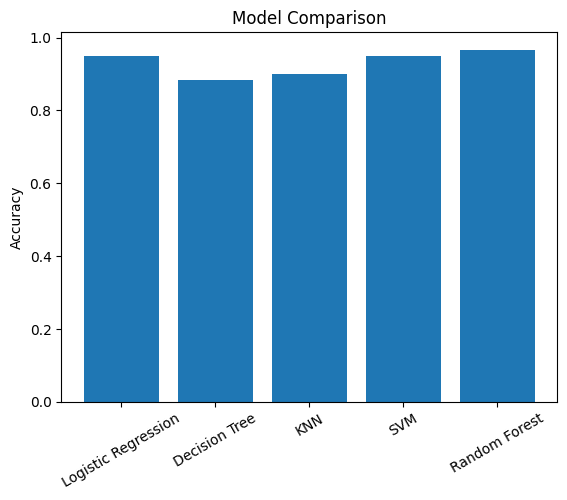

In [11]:
models = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(models, accuracies)
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

#Best Model

In [12]:
best_model = max(results, key=results.get)
print("Best Model is:", best_model)

Best Model is: Random Forest


#UNIQUE FEATURE STARTS HERE

#Explainable AI (Feature Importance)

In [13]:
feature_importance = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

           Feature  Importance
5         stenosis    0.328663
6         diameter    0.192994
8               bp    0.170037
7      cholesterol    0.141292
10             bmi    0.050915
0              age    0.036992
2         exercise    0.020956
1          smoking    0.018948
9       heart_rate    0.017190
3             diet    0.012436
4   family_history    0.009576


#Plot Feature Importance

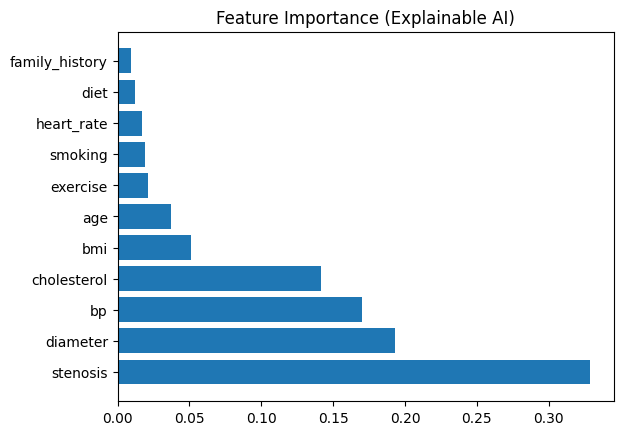

In [14]:
plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance (Explainable AI)")
plt.show()

#Risk Category Function

In [15]:
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

#Suggestion System

In [16]:
def give_suggestion(row):
    suggestions = []

    if row["cholesterol"] > 0:
        suggestions.append("Reduce cholesterol intake")
    if row["bmi"] > 0:
        suggestions.append("Maintain healthy weight")
    if row["exercise"] < 2:
        suggestions.append("Increase physical activity")

    return suggestions

#Test Unique System

In [17]:
# Take one sample
sample = X_test.iloc[0]

# Predict probability
prob = rf.predict_proba([sample])[0][1]

print("Risk Probability:", prob)
print("Risk Level:", risk_category(prob))

print("Suggestions:", give_suggestion(sample))

Risk Probability: 0.96
Risk Level: High Risk
Suggestions: ['Maintain healthy weight', 'Increase physical activity']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#User Input System

In [18]:
print("Enter Patient Details:")

age = float(input("Age: "))
cholesterol = float(input("Cholesterol: "))
bp = float(input("Blood Pressure: "))
heart_rate = float(input("Heart Rate: "))
bmi = float(input("BMI: "))
exercise = float(input("Exercise Level (0-4): "))
diet = float(input("Diet Level (1-9): "))
smoking = int(input("Smoking (0 = No, 1 = Yes): "))
family_history = int(input("Family History (0 = No, 1 = Yes): "))
stenosis = float(input("Stenosis: "))
diameter = float(input("Diameter: "))

Enter Patient Details:
Age: 56
Cholesterol: 456
Blood Pressure: 98
Heart Rate: 98
BMI: 89
Exercise Level (0-4): 02
Diet Level (1-9): 01
Smoking (0 = No, 1 = Yes): 1
Family History (0 = No, 1 = Yes): 1
Stenosis: 55.67
Diameter: 676.5


#Convert Input → DataFrame

In [19]:
user_data = pd.DataFrame([{
    "age": age,
    "cholesterol": cholesterol,
    "bp": bp,
    "heart_rate": heart_rate,
    "bmi": bmi,
    "exercise": exercise,
    "diet": diet,
    "smoking": smoking,
    "family_history": family_history,
    "stenosis": stenosis,
    "diameter": diameter
}])

user_data

,age,cholesterol,bp,heart_rate,bmi,exercise,diet,smoking,family_history,stenosis,diameter
0,56.0,456.0,98.0,98.0,89.0,2.0,1.0,1,1,55.67,676.5


#Scale Input (IMPORTANT)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)   # same scaling

# Reorder user_data columns to match X's column order
user_data = user_data[X.columns]

user_scaled = scaler.transform(user_data)

#Prediction + Risk + Suggestion

In [24]:
# Prediction
prob = rf.predict_proba(user_scaled)[0][1]

print("Prediction Probability:", prob)
print("Risk Level:", risk_category(prob))

# Suggestions
print("Suggestions:", give_suggestion(user_data.iloc[0]))

Prediction Probability: 0.82
Risk Level: High Risk
Suggestions: ['Reduce cholesterol intake', 'Maintain healthy weight']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#Multi-User Input System

In [26]:
while True:
    print("\n--- Enter Patient Details ---")

    age = float(input("Age: "))
    cholesterol = float(input("Cholesterol: "))
    bp = float(input("Blood Pressure: "))
    heart_rate = float(input("Heart Rate: "))
    bmi = float(input("BMI: "))
    exercise = float(input("Exercise Level (0-4): "))
    diet = float(input("Diet Level (1-9): "))
    smoking = int(input("Smoking (0 = No, 1 = Yes): "))
    family_history = int(input("Family History (0 = No, 1 = Yes): "))
    stenosis = float(input("Stenosis: "))
    diameter = float(input("Diameter: "))

    user_data = pd.DataFrame([{
        "age": age,
        "cholesterol": cholesterol,
        "bp": bp,
        "heart_rate": heart_rate,
        "bmi": bmi,
        "exercise": exercise,
        "diet": diet,
        "smoking": smoking,
        "family_history": family_history,
        "stenosis": stenosis,
        "diameter": diameter
    }])

    # Reorder user_data columns to match X's column order
    user_data = user_data[X.columns]

    # Scale
    user_scaled = scaler.transform(user_data)

    # Prediction
    prob = rf.predict_proba(user_scaled)[0][1]
    prediction = rf.predict(user_scaled)[0]

    print("\n--- RESULT ---")

    # 1. Risk Probability
    print("Risk Probability:", round(prob, 3))

    # 2. Risk Category
    print("Risk Level:", risk_category(prob))

    # 3. Final Prediction
    print("Prediction:", "High Risk" if prediction == 1 else "Low Risk")

    # 4. Suggestions
    print("Suggestions:", give_suggestion(user_data.iloc[0]))

    # 5. Confidence
    confidence = max(prob, 1 - prob)
    print("Model Confidence:", round(confidence, 3))

    # Continue or stop
    cont = input("\nDo you want to test another patient? (yes/no): ")
    if cont.lower() != "yes":
        print("System exited.")
        break


--- Enter Patient Details ---
Age: 45
Cholesterol: -0.2345678
Blood Pressure: 120
Heart Rate: 99
BMI: -0.4489875
Exercise Level (0-4): 01
Diet Level (1-9): 01
Smoking (0 = No, 1 = Yes): 1
Family History (0 = No, 1 = Yes): 1
Stenosis: 0.319567654
Diameter: 78.98


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



--- RESULT ---
Risk Probability: 0.75
Risk Level: High Risk
Prediction: High Risk
Suggestions: ['Increase physical activity']
Model Confidence: 0.75

Do you want to test another patient? (yes/no): yes

--- Enter Patient Details ---
Age: 76
Cholesterol: 76866
Blood Pressure: 130
Heart Rate: 99
BMI: -0.9878876
Exercise Level (0-4): 01
Diet Level (1-9): 02
Smoking (0 = No, 1 = Yes): 1
Family History (0 = No, 1 = Yes): 1
Stenosis: -0.5678943
Diameter: -789.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



--- RESULT ---
Risk Probability: 0.71
Risk Level: High Risk
Prediction: High Risk
Suggestions: ['Reduce cholesterol intake', 'Increase physical activity']
Model Confidence: 0.71

Do you want to test another patient? (yes/no): no
System exited.
